In [1]:
from pylab import *

the difference came from running the simulation for a longer or shorter time.

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.5
Plasticnet version  0.1.14
macOS-15.5-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
base_sim_dir=f"sims-2025-06-10 debug"
if not os.path.exists(base_sim_dir):
    print("new")
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-06-10 debug


In [4]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [5]:
def blur_jitter_deficit(blur=[2.5,-1],
                        noise=[0.1,.1],
                        rf_size=19,eta=2e-6,
                        mu_c=0,sigma_c=0,    
                        mu_r=0,sigma_r=0,
                        number_of_neurons=10,
                        total_time=8*day,
                        save_interval=1*hour):

    # base_image_file="asdf/bbsk081604_all.asdf"
    # print("Override Base Image File:",base_image_file)
    
    images=[]
    dt=200*ms
    
    # for bv in blur:
    #     if bv<=0:
    #         im=pi5.filtered_images(
    #                             base_image_file,
    #                             {'type':'dog','sd1':1,'sd2':3},
    #                             {'type':'norm'},
    #                             )
    #     else:
    #         im=pi5.filtered_images(
    #                                 base_image_file,
    #                                 {'type':'blur','size':bv},
    #                                 {'type':'dog','sd1':1,'sd2':3},
    #                                 {'type':'norm'},
    #                                 )
    #     images.append(im)
        
        
    dt=200*ms        
    pre1=pn.neurons.natural_images_with_jitter('cache_images/cache_images_c2e0829f3e61ca9a4b271b0f7c2ee1f1.asdf',
                                                rf_size=rf_size,
                                                time_between_patterns=dt,
                                                sigma_r=0,
                                                sigma_c=0,
                                                verbose=False)

    pre2=pn.neurons.natural_images_with_jitter('cache_images/cache_images_c2e0829f3e61ca9a4b271b0f7c2ee1f1.asdf',
                                                rf_size=rf_size,
                                                other_channel=pre1,
                                                time_between_patterns=dt,
                                                mu_r=mu_r,mu_c=mu_c,
                                                sigma_r=sigma_r,sigma_c=sigma_c,
                                                verbose=False)



    sigma=noise
    pre1+=pn.neurons.process.add_noise_normal(0,sigma)

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,sigma)

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=dt

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                             k_mat=linspace(1,20,40)/19.0*pi,)

    return sim,[pre,post],[c]

In [6]:
%%time
blur=-1
noise=0.1
eta=2e-6
number_of_neurons=20
mu_c=10
sigma_c=0

sfname=f"{base_sim_dir}/sim1.asdf"

seq=pn.Sequence()

t=8*day*2
ts=1*hour

seq+=blur_jitter_deficit(blur=[blur,-1],
                             total_time=t,
                            noise=noise,eta=eta,number_of_neurons=number_of_neurons,
                            mu_c=mu_c,sigma_c=sigma_c,
                            save_interval=ts)


seq.run(display_hash=True)
pn.save(sfname,seq) 


 [#############################100% (ETA: 0.0 s)#############################].] Sequence Time Elapsed...3 m, 10.13 s
CPU times: user 3min 12s, sys: 1.58 s, total: 3min 14s
Wall time: 3min 14s


In [7]:
R=Results(sfname)

μ1,μ2=R.μσ[0][0]
σ1,σ2=R.μσ[1][0]
print(μ1,μ2,σ1,σ2)

22.05497637728907 22.380397286981562 1.895019958477593 1.8003584906418555


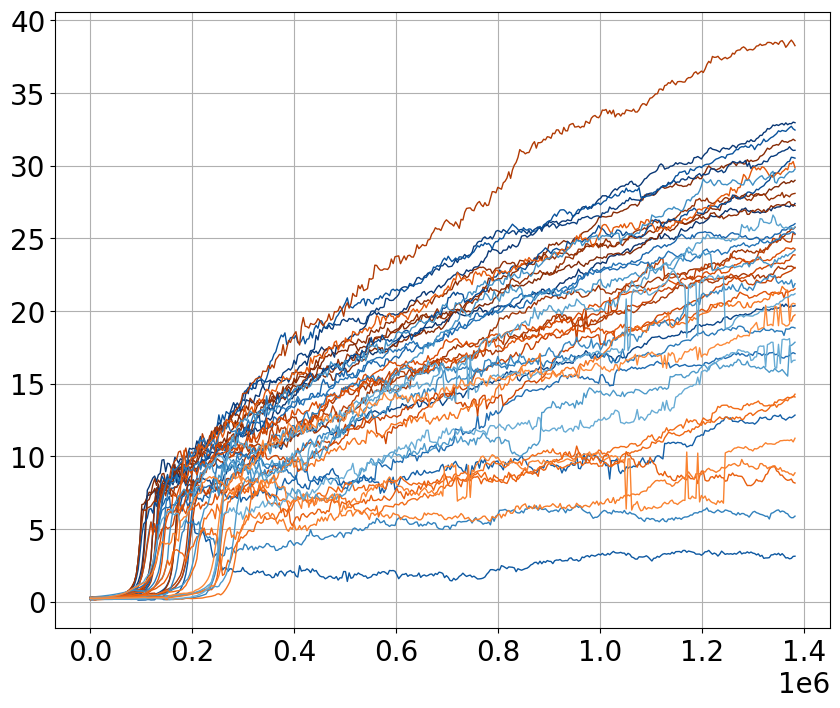

In [8]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(number_of_neurons):
    plot(R.t,R.y[:,n,0],'-',lw=1,color=Blues2(v[n]));
    plot(R.t,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));

In [9]:
def deficit(blur=[2.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day,
           save_interval=1*hour):

    dt=200*ms
    # base_image_file='asdf/bbsk081604_all.asdf'
    # print("Base Image File:",base_image_file)
    
    # im=[]
    # for b in blur:
    #     if b<0:
    #         im+=[pi5.filtered_images(base_image_file,
    #                                 {'type':'norm'},
    #                                 {'type':'dog','sd1':1,'sd2':3}
    #                                 )
    #             ]
    #     else:
    #         im+=[pi5.filtered_images(base_image_file,
    #                                 {'type':'blur','size':b},
    #                                 {'type':'norm'},
    #                                 {'type':'dog','sd1':1,'sd2':3}
    #                                 )
    #             ]

    pre1=pn.neurons.natural_images_with_jitter('cache_images/cache_images_c2e0829f3e61ca9a4b271b0f7c2ee1f1.asdf',
                                                time_between_patterns=dt,
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter('cache_images/cache_images_c2e0829f3e61ca9a4b271b0f7c2ee1f1.asdf',rf_size=rf_size,
                                                time_between_patterns=dt,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=dt

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]




In [10]:
%%time
mu_r=0
sigma_r=0

seq=pn.Sequence()
# deliberately use a standard deficit, with it's own eta and noise
seq+=deficit(number_of_neurons=number_of_neurons,
             noise=[noise,noise],blur=[blur,-1],
            total_time=t,save_interval=ts,
             mu_c=mu_c,sigma_c=sigma_c,
            mu_r=mu_r,sigma_r=sigma_r,) 


seq.run(display_hash=True)
pn.save(sfname,seq) 


 [#############################100% (ETA: 0.0 s)#############################].] Sequence Time Elapsed...3 m, 11.48 s
CPU times: user 3min 14s, sys: 1.51 s, total: 3min 15s
Wall time: 3min 15s


In [11]:
t

1382400

In [12]:
R=Results(sfname)

μ1,μ2=R.μσ[0][0]
σ1,σ2=R.μσ[1][0]
print(μ1,μ2,σ1,σ2)

23.60692093011779 21.275799353423487 1.7635084735481932 2.279529472565907


In [13]:
R.y.shape

(385, 20, 2)

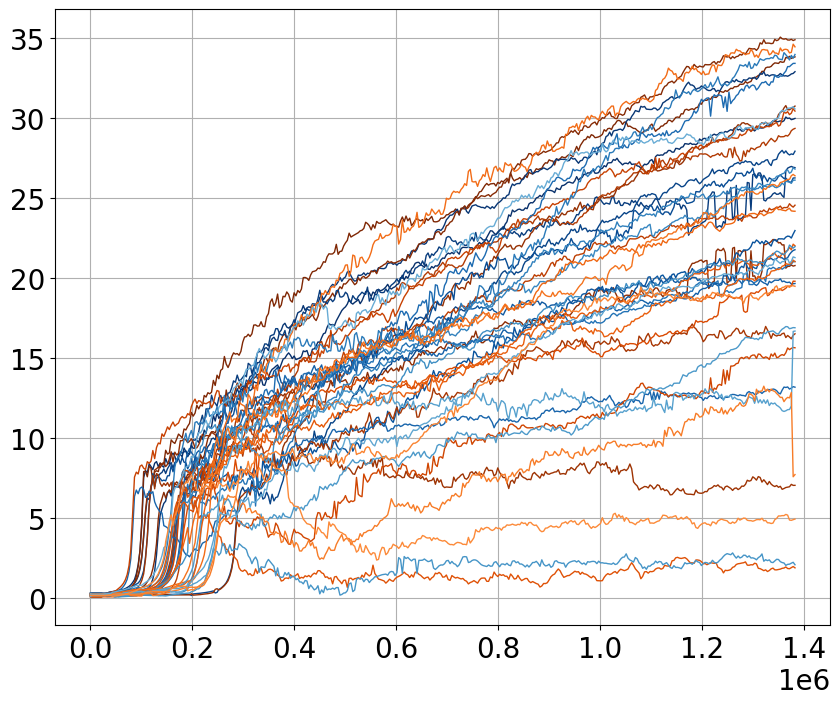

In [14]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(number_of_neurons):
    plot(R.t,R.y[:,n,0],'-',lw=1,color=Blues2(v[n]));
    plot(R.t,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));

In [15]:
im2=pi5.asdf_load_images('cache_images/cache_images_0d75e3da03ce813da7b40daf86657d7d.asdf')
im1=pi5.asdf_load_images('cache_images/cache_images_c2e0829f3e61ca9a4b271b0f7c2ee1f1.asdf')

In [16]:
im1.keys()

dict_keys(['im_scale_shift', 'im'])

In [17]:
len(im1['im']),len(im2['im'])

(118, 118)

In [18]:
im1['im_scale_shift'],im2['im_scale_shift']

([0.0005452054100309117, -15.87986303848904],
 [0.0005452054100309125, -15.879863038489077])

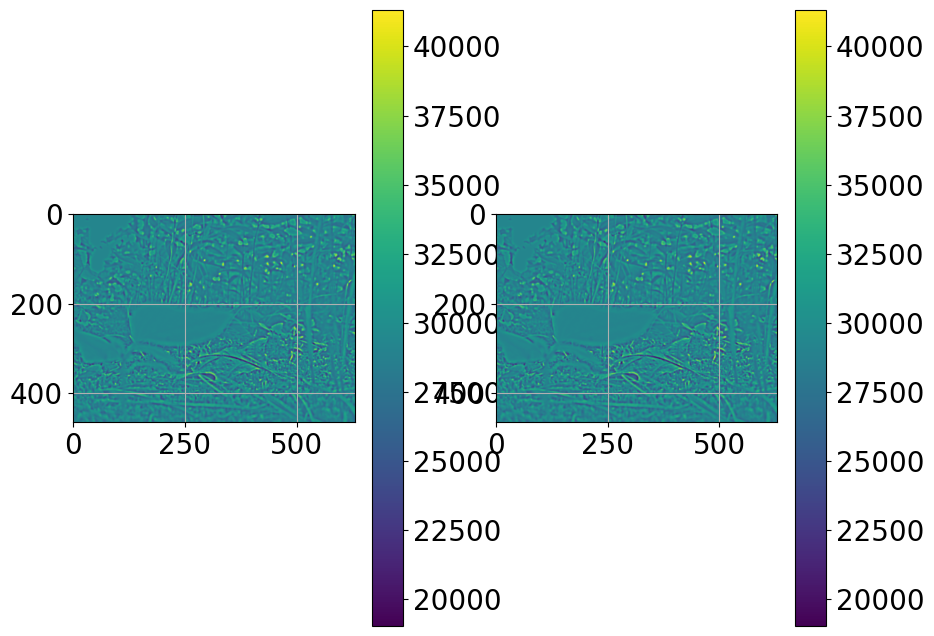

In [19]:
subplot(1,2,1)
imshow(im1['im'][0])
colorbar()
subplot(1,2,2)
imshow(im2['im'][0])
colorbar()

In [20]:
any(im1['im'][0]-im2['im'][0])

False

In [21]:
print([any(_1-_2) for _1,_2 in zip(im1['im'],im2['im'])])

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
